# 06: Exetended Evaluation Protocol

Section 3.5's shared evaluation setup for comparing the eight representations (`raw`, `classical`, `ft_transformer`, `subtab`, `scarf`, `ft_transformer_no_text`, `subtab_no_text`, `scarf_no_text`) built in `04_feature_encoding.ipynb`/`05_embedding_paradigms.ipynb`.

## Setup

In [1]:
%matplotlib inline

import os

# torch bundles its own OpenMP runtime (libiomp5md.dll) while
# numpy/pandas/scikit-learn pull in MKL's (libomp.dll/libiomp5md.dll) --
# loading both into one process aborts the kernel outright ("OMP: Error
# #15: Initializing ..., but found ... already initialized"), not a
# Python exception, so it shows up as a bare kernel crash with no
# traceback. Must be set before numpy/torch are imported anywhere below.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import math
import sys
from functools import partial
from pathlib import Path

from IPython.display import display

import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config
from src.evaluation import eval_setup
from src.report import savefig

sns.set_theme(style="whitegrid")

EVALUATION_DIR = config.EVALUATION_DIR
FINAL_DIR = config.FINAL_DIR

FIGURES_DIR = config.FIGURES_DIR / "06_extend"
savefig = partial(savefig, figures_dir=FIGURES_DIR)

## 1. Load Representation

### Load and align

Loads all eight representations and the candidate's own splits, then asserts row alignment between them before anything downstream trusts it.

In [2]:
representations, representation_ids = eval_setup.load_representations(config.MODELS_DIR)
candidate_splits = eval_setup.load_candidate_splits(FINAL_DIR)

eval_setup.assert_row_alignment(representations, representation_ids, candidate_splits)

for repr_name in eval_setup.REPR_NAMES:
    for split in config.SPLIT_NAMES:
        shape = representations[repr_name][split].shape
        print(f"representations[{repr_name!r}][{split!r}]: {shape}")

for split in config.SPLIT_NAMES:
    print(f"candidate_splits[{split!r}]: {candidate_splits[split].shape}")

representations['raw']['train']: (8403, 20)
representations['raw']['val']: (1050, 20)
representations['raw']['test']: (1051, 20)
representations['classical']['train']: (8403, 4286)
representations['classical']['val']: (1050, 4286)
representations['classical']['test']: (1051, 4286)
representations['ft_transformer']['train']: (8403, 192)
representations['ft_transformer']['val']: (1050, 192)
representations['ft_transformer']['test']: (1051, 192)
representations['subtab']['train']: (8403, 1024)
representations['subtab']['val']: (1050, 1024)
representations['subtab']['test']: (1051, 1024)
representations['scarf']['train']: (8403, 256)
representations['scarf']['val']: (1050, 256)
representations['scarf']['test']: (1051, 256)
representations['ft_transformer_no_text']['train']: (8403, 192)
representations['ft_transformer_no_text']['val']: (1050, 192)
representations['ft_transformer_no_text']['test']: (1051, 192)
representations['subtab_no_text']['train']: (8403, 1024)
representations['subtab_n

In [3]:
raw_test_std = representations["raw"]["test"].std()
display(raw_test_std)

revenue                         4.031697
runtime                        31.168614
budget                          3.664618
popularity                      1.003698
release_year                   17.844512
original_language               1.523867
genres                          1.090498
production_companies            1.827695
production_countries            0.900990
spoken_languages                0.984059
keywords                        4.971739
has_genres                      0.092185
has_keywords                    0.311119
has_production_companies        0.218931
has_production_countries        0.198184
has_spoken_languages            0.158284
has_overview                    0.043602
release_month_sin               0.706215
release_month_cos               0.706422
title_differs_from_original     0.385019
dtype: float64

## 2. Setup for Evaluation

### Genre label

Derives the genre label (first-listed genre) and a `valid_mask` marking rows with no first genre to exclude, rather than fabricating a fallback value. Independently re-checks the excluded-row count against `candidate_splits` directly.

In [4]:
genre_labels, genre_valid_mask = eval_setup.derive_genre_label(candidate_splits)

print("genre_labels['test'].value_counts():")
print(genre_labels["test"].value_counts())
print()

for split in config.SPLIT_NAMES:
    n_distinct = genre_labels[split].nunique()
    print(f"{split}: {n_distinct} distinct genres")
print()

# Independent re-check of the excluded-row count derive_genre_label
# already printed -- recomputed here directly from
# candidate_splits' own genres column (empty list, not NaN), not
# trusted from that prior cell's stdout.
for split in config.SPLIT_NAMES:
    is_empty = candidate_splits[split][eval_setup.GENRE_COL].apply(len) == 0
    print(f"{split}: {is_empty.sum()} row(s) had an empty genres list (excluded)")

derive_genre_label: train: 55 row(s) have no first genre and are excluded from clustering labels
derive_genre_label: val: 9 row(s) have no first genre and are excluded from clustering labels
derive_genre_label: test: 9 row(s) have no first genre and are excluded from clustering labels
genre_labels['test'].value_counts():
genres
Drama              264
Comedy             216
Action             157
Horror              60
Adventure           51
Thriller            46
Crime               46
Animation           38
Romance             29
Science Fiction     26
Documentary         21
Fantasy             21
Family              16
Mystery             15
War                 12
Music               12
Western              7
History              5
Name: count, dtype: int64

train: 19 distinct genres
val: 19 distinct genres
test: 18 distinct genres

train: 55 row(s) had an empty genres list (excluded)
val: 9 row(s) had an empty genres list (excluded)
test: 9 row(s) had an empty genres list (excluded)

### Shared XGBoost config

`eval_setup.SharedXGBConfig`, the one fixed, un-tuned config every representation is scored with. Also builds `raw_features_safe`/`classical_features_safe`.

In [5]:
import dataclasses

xgb_config = eval_setup.SharedXGBConfig()

print("dataclasses.asdict(xgb_config):")
print(dataclasses.asdict(xgb_config))
print()
print("xgb_config.regressor_kwargs():")
print(xgb_config.regressor_kwargs())
print()
print("xgb_config.classifier_kwargs():")
print(xgb_config.classifier_kwargs())

raw_features_safe = {
    split: eval_setup.drop_sensitive_attribute_columns(representations["raw"][split], "raw")
    for split in config.SPLIT_NAMES
}
classical_features_safe = {
    split: eval_setup.drop_sensitive_attribute_columns(
        representations["classical"][split], "classical"
    )
    for split in config.SPLIT_NAMES
}

raw_before = representations["raw"]["test"].shape[1]
raw_after = raw_features_safe["test"].shape[1]
classical_before = representations["classical"]["test"].shape[1]
classical_after = classical_features_safe["test"].shape[1]

print()
print(f"raw (test split): {raw_before} columns before -> {raw_after} after (dropped {raw_before - raw_after})")
print(
    f"classical (test split): {classical_before} columns before -> "
    f"{classical_after} after (dropped {classical_before - classical_after})"
)

dataclasses.asdict(xgb_config):
{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1}

xgb_config.regressor_kwargs():
{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}

xgb_config.classifier_kwargs():
{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1, 'objective': 'multi:softprob', 'eval_metric': 'mlogloss'}
drop_sensitive_attribute_columns[raw]: dropped ['original_language']
drop_sensitive_attribute_columns[raw]: dropped ['original_language']
drop_sensitive_attribute_columns[raw]: dropped ['original_language']
drop_sensitive_attribute_columns[classical]: dropped ['original_language_oov', 'original_language_en', 'origina

## 3. Representation Quality

### Clustering

`clustering_metrics.run_all` (Eq. 3.16-3.18) against the test split, for every representation. Uses the original `raw`/`classical` frames, not the sensitive-attribute-safe versions -- that guard is only needed for the Section 5 recoverability probe. Rows with no first genre (`genre_valid_mask["test"]`, Section 2) are excluded before computing Table 4.2 -- both `X` and the label are filtered to the mask first; the exact excluded count is printed above the table.

**Table 4.2's `silhouette` column is a single seeded 200-row subsample of the (mask-filtered) test split, not the full split** -- `calinski_harabasz`/`davies_bouldin` use the full (mask-filtered) split. The cell after Table 4.2 discloses how much that single 200-row draw could vary, via `clustering_metrics.run_silhouette_variance`'s mean±std over 20 seeded draws.

In [6]:
from src.evaluation import clustering_metrics

mask_test = genre_valid_mask["test"].to_numpy()
labels_test_masked = genre_labels["test"][mask_test]

repr_arrays = {
    repr_name: representations[repr_name]["test"].to_numpy()[mask_test]
    for repr_name in eval_setup.REPR_NAMES
}

print(
    f"Table 4.2: {mask_test.sum()} of {len(mask_test)} test rows used "
    f"({(~mask_test).sum()} excluded for having no first genre)"
)
clustering_table = clustering_metrics.run_all(
    repr_arrays, labels_test_masked, config.RANDOM_SEED
)
display(clustering_table)

Table 4.2: 1042 of 1051 test rows used (9 excluded for having no first genre)


,silhouette,calinski_harabasz,davies_bouldin
raw,-0.297984,5.129236,9.868451
classical,-0.085134,5.554086,5.081278
ft_transformer,-0.279115,5.230553,7.900167
subtab,-0.118872,9.698949,5.143625
scarf,-0.264919,3.702495,8.861269
ft_transformer_no_text,-0.296572,7.001909,6.588351
subtab_no_text,-0.135893,6.980652,5.347375
scarf_no_text,-0.264927,12.319800,5.136824


#### Check number of classess in genre

In [7]:
from sklearn.utils import check_random_state

from src import config
from src.evaluation import eval_setup

# Reproduce candidate_splits / genre_labels / mask exactly as 06 does
candidate_splits = eval_setup.load_candidate_splits(config.FINAL_DIR)
genre_labels, genre_valid_mask = eval_setup.derive_genre_label(candidate_splits)

mask_test = genre_valid_mask["test"].to_numpy()
labels_test_masked = genre_labels["test"][mask_test]

# Count 1: distinct genres in the full mask-filtered set (VRC/DBI's input)
full_set_counts = labels_test_masked.value_counts()

# sklearn's silhouette_score internal subsampling (sklearn 1.9.0, confirmed
# via inspect.getsource): indices = check_random_state(random_state).permutation(X.shape[0])[:sample_size]
random_state_obj = check_random_state(config.RANDOM_SEED)
sample_indices = random_state_obj.permutation(len(labels_test_masked))[:200]

# Count 2: distinct genres among only the 200 sklearn-selected rows
sampled_labels = labels_test_masked.to_numpy()[sample_indices]
sampled_counts = pd.Series(sampled_labels).value_counts()

missing = set(full_set_counts.index) - set(sampled_counts.index)

print(f"full set ({len(labels_test_masked)} rows): {full_set_counts.shape[0]} distinct genres")
print(f"200-row subsample: {sampled_counts.shape[0]} distinct genres")
print(f"genres missing from the subsample: {sorted(missing) if missing else 'none'}")

derive_genre_label: train: 55 row(s) have no first genre and are excluded from clustering labels
derive_genre_label: val: 9 row(s) have no first genre and are excluded from clustering labels
derive_genre_label: test: 9 row(s) have no first genre and are excluded from clustering labels
full set (1042 rows): 18 distinct genres
200-row subsample: 15 distinct genres
genres missing from the subsample: ['Family', 'War', 'Western']


#### Silhouette subsample variance

`clustering_metrics.run_silhouette_variance` per representation: 20 seeded 200-row draws (seed `config.RANDOM_SEED + i`), reported as mean±std -- discloses how much Table 4.2's single silhouette draw could have moved under a different seed.

In [8]:
silhouette_variance_rows = {
    repr_name: clustering_metrics.run_silhouette_variance(
        repr_arrays[repr_name], labels_test_masked, config.RANDOM_SEED
    )
    for repr_name in eval_setup.REPR_NAMES
}

silhouette_variance_table = pd.DataFrame.from_dict(silhouette_variance_rows, orient="index")
display(silhouette_variance_table)

,mean,std
raw,-0.388115,0.035302
classical,-0.098678,0.028066
ft_transformer,-0.282943,0.039946
subtab,-0.121672,0.013899
scarf,-0.320590,0.049313
ft_transformer_no_text,-0.278875,0.031622
subtab_no_text,-0.143804,0.014081
scarf_no_text,-0.255323,0.028826


#### Standardisation scale-artefact check (diagnostic, not saved)

One-off diagnostic -- not a sixth condition in Table 4.2, not saved to `clustering_metrics.csv`. Fits `sklearn.preprocessing.StandardScaler` on `raw`'s train split, applies it to the same (mask-filtered) test matrix already used for Table 4.2, and reruns `compute_clustering_metrics` with the identical labels/`random_state`/`silhouette_sample_size` used for `raw`'s Table 4.2 row. Prints `raw`'s silhouette as-is vs standardised, side by side, so Chapter 4's scale-artefact claim can cite a measured before/after number.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(representations["raw"]["train"].to_numpy())

raw_test_standardised = scaler.transform(representations["raw"]["test"].to_numpy())[mask_test]

standardised_metrics = clustering_metrics.compute_clustering_metrics(
    raw_test_standardised, labels_test_masked, config.RANDOM_SEED
)

raw_silhouette_as_is = clustering_table.loc["raw", "silhouette"]
print(f"raw silhouette, as-is:        {raw_silhouette_as_is:.4f}")
print(f"raw silhouette, standardised: {standardised_metrics['silhouette']:.4f}")

raw silhouette, as-is:        -0.2980
raw silhouette, standardised: -0.2206


#### Save clustering metrics

Sanity-checks `silhouette` in `[-1, 1]` and `davies_bouldin >= 0` before saving to `EVALUATION_DIR / "06_extend_clustering_metrics.csv"`.

In [10]:
assert clustering_table["silhouette"].between(-1, 1).all(), (
    "silhouette values out of [-1, 1] range:\n"
    f"{clustering_table.loc[~clustering_table['silhouette'].between(-1, 1), 'silhouette']}"
)
assert (clustering_table["davies_bouldin"] >= 0).all(), (
    "davies_bouldin values below 0:\n"
    f"{clustering_table.loc[clustering_table['davies_bouldin'] < 0, 'davies_bouldin']}"
)
print("Sanity checks passed: silhouette in [-1, 1], davies_bouldin >= 0")

EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

clustering_metrics_path = EVALUATION_DIR / "06_extend_clustering_metrics.csv"
clustering_table.to_csv(clustering_metrics_path)
print(f"Saved: {clustering_metrics_path}")

Sanity checks passed: silhouette in [-1, 1], davies_bouldin >= 0
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\evaluation\06_extend_clustering_metrics.csv


#### Clustering-index rank agreement (bump chart)

Ranks each representation 1 (best) to 5 (worst) on each of silhouette, VRC, and DBI,
directly from `clustering_table` -- no new computation beyond ranking values
already saved to Table 4.2. Crossing lines show where the three indices
disagree on ordering; parallel lines show where they agree.

,silhouette,calinski_harabasz,davies_bouldin
raw,8,7,8
classical,1,5,1
ft_transformer,6,6,6
subtab,2,2,3
scarf,4,8,7
ft_transformer_no_text,7,3,5
subtab_no_text,3,4,4
scarf_no_text,5,1,2


Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\06_extend\06_clustering_rank_bumpchart.png


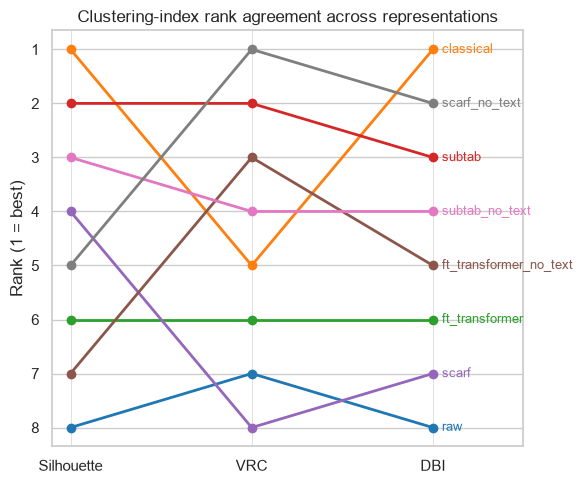

In [34]:
DIRECTION = {
    "silhouette": "higher_better",
    "calinski_harabasz": "higher_better",
    "davies_bouldin": "lower_better",
}
AXIS_LABELS = {
    "silhouette": "Silhouette",
    "calinski_harabasz": "VRC",
    "davies_bouldin": "DBI",
}
AXIS_ORDER = ["silhouette", "calinski_harabasz", "davies_bouldin"]

ranks = pd.DataFrame(index=clustering_table.index)
for col, direction in DIRECTION.items():
    ascending = direction == "lower_better"
    ranks[col] = clustering_table[col].rank(ascending=ascending, method="min").astype(int)

display(ranks)

fig, ax = plt.subplots(figsize=(6, 5))
colors = plt.get_cmap("tab10").colors[: len(ranks)]

x_positions = range(len(AXIS_ORDER))
for (repr_name, row), color in zip(ranks.iterrows(), colors):
    y_values = [row[col] for col in AXIS_ORDER]
    ax.plot(x_positions, y_values, marker="o", color=color, label=repr_name, linewidth=2)
    ax.text(x_positions[-1] + 0.05, y_values[-1], repr_name, color=color, va="center", fontsize=9)

ax.set_xticks(list(x_positions))
ax.set_xticklabels([AXIS_LABELS[col] for col in AXIS_ORDER])
ax.set_yticks(range(1, len(ranks) + 1))
ax.set_ylabel("Rank (1 = best)")
ax.invert_yaxis()
ax.set_xlim(-0.1, len(AXIS_ORDER) - 1 + 0.5)
ax.set_title("Clustering-index rank agreement across representations")
ax.grid(axis="x", color="lightgrey", linewidth=0.5)

fig.tight_layout()
savefig(fig, "06_clustering_rank_bumpchart.png")
plt.show()

### Visualisation

t-SNE parameter check, fit, and plot for each representation's test-split geometry.

#### t-SNE parameter check

`tsne_viz.kobak_berens_tsne_params` against the real test-split size, printed next to sklearn's own defaults so the "validated, not default" claim is checkable at a glance. Both floors (perplexity/learning-rate) bind at this split size.

In [11]:
from src.evaluation import tsne_viz

n_test = len(genre_labels["test"])
tsne_params = tsne_viz.kobak_berens_tsne_params(n_test)

print(f"n_test = {n_test}")
print(f"kobak_berens_tsne_params({n_test}) = {tsne_params}")
print()
print(f"  n_test / 100 = {n_test / 100:.2f}  (perplexity floor 30 binds: {n_test / 100 < 30})")
print(f"  n_test / 12  = {n_test / 12:.2f}  (learning_rate floor 200 binds: {n_test / 12 < 200})")
print()
print("Comparison against sklearn's own TSNE(...) defaults:")
print(f"  perplexity:    kobak_berens={tsne_params['perplexity']!r}   vs  sklearn default=30")
print(f"  learning_rate: kobak_berens={tsne_params['learning_rate']!r}  vs  sklearn default='auto'")

assert tsne_params["perplexity"] == 30, (
    f"expected perplexity=30 (floor should bind at n_test={n_test}), "
    f"got {tsne_params['perplexity']}"
)
assert tsne_params["learning_rate"] == 200, (
    f"expected learning_rate=200 (floor should bind at n_test={n_test}), "
    f"got {tsne_params['learning_rate']}"
)
print("\nBoth floors confirmed binding at this split size, as expected.")

n_test = 1051
kobak_berens_tsne_params(1051) = {'perplexity': 30, 'learning_rate': 200}

  n_test / 100 = 10.51  (perplexity floor 30 binds: True)
  n_test / 12  = 87.58  (learning_rate floor 200 binds: True)

Comparison against sklearn's own TSNE(...) defaults:
  perplexity:    kobak_berens=30   vs  sklearn default=30
  learning_rate: kobak_berens=200  vs  sklearn default='auto'

Both floors confirmed binding at this split size, as expected.


#### Fit t-SNE per representation

The slowest cell in this notebook. `max_samples=100` is kept: 250, 500, and the full 1051-row test split were all tested directly under this notebook's own thread-pinned setup (cell 2's `OMP_NUM_THREADS`/`OPENBLAS_NUM_THREADS`/`MKL_NUM_THREADS=1`), and every one of those crashed the kernel on the wider representations (`classical`, `subtab`) -- 100 is the verified ceiling in this exact environment, not a value inherited from an earlier or different setup. Stores embeddings and the sample indices together so labels can be aligned to the subsample later.

In [12]:
import time

from src.evaluation import tsne_viz

tsne_embeddings = {}
tsne_sample_indices = {}

for repr_name in eval_setup.REPR_NAMES:
    X = representations[repr_name]["test"].to_numpy()

    start = time.time()
    embedding, sample_indices = tsne_viz.fit_tsne(
        X, config.RANDOM_SEED, max_samples=100
    )
    elapsed = time.time() - start

    tsne_embeddings[repr_name] = embedding
    tsne_sample_indices[repr_name] = sample_indices
    print(f"{repr_name}: {elapsed:.1f}s")

fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
raw: 0.5s
fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
classical: 0.8s
fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
ft_transformer: 0.5s
fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
subtab: 0.7s
fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
scarf: 0.7s
fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
ft_transformer_no_text: 0.5s
fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
subtab_no_text: 0.5s
fit_tsne: fitting 100/1051 rows, perplexity=30, learning_rate=200
scarf_no_text: 0.7s


#### t-SNE grid

One panel per representation, coloured by genre label, aligned via each panel's own sample indices. One genre-to-colour mapping is shared across all panels. t-SNE itself was fit on the full (unmasked) test split (Section 6), so a sampled point with no first genre (`NaN` in `genre_labels["test"]`) is drawn in a fixed grey rather than crashing or being silently dropped. Reflows into a multi-row grid (4 columns) rather than one long row, since `REPR_NAMES` now has eight entries. Saved via `src/report.py`'s `savefig`.

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\06_extend\06_extend_tsne_grid.png


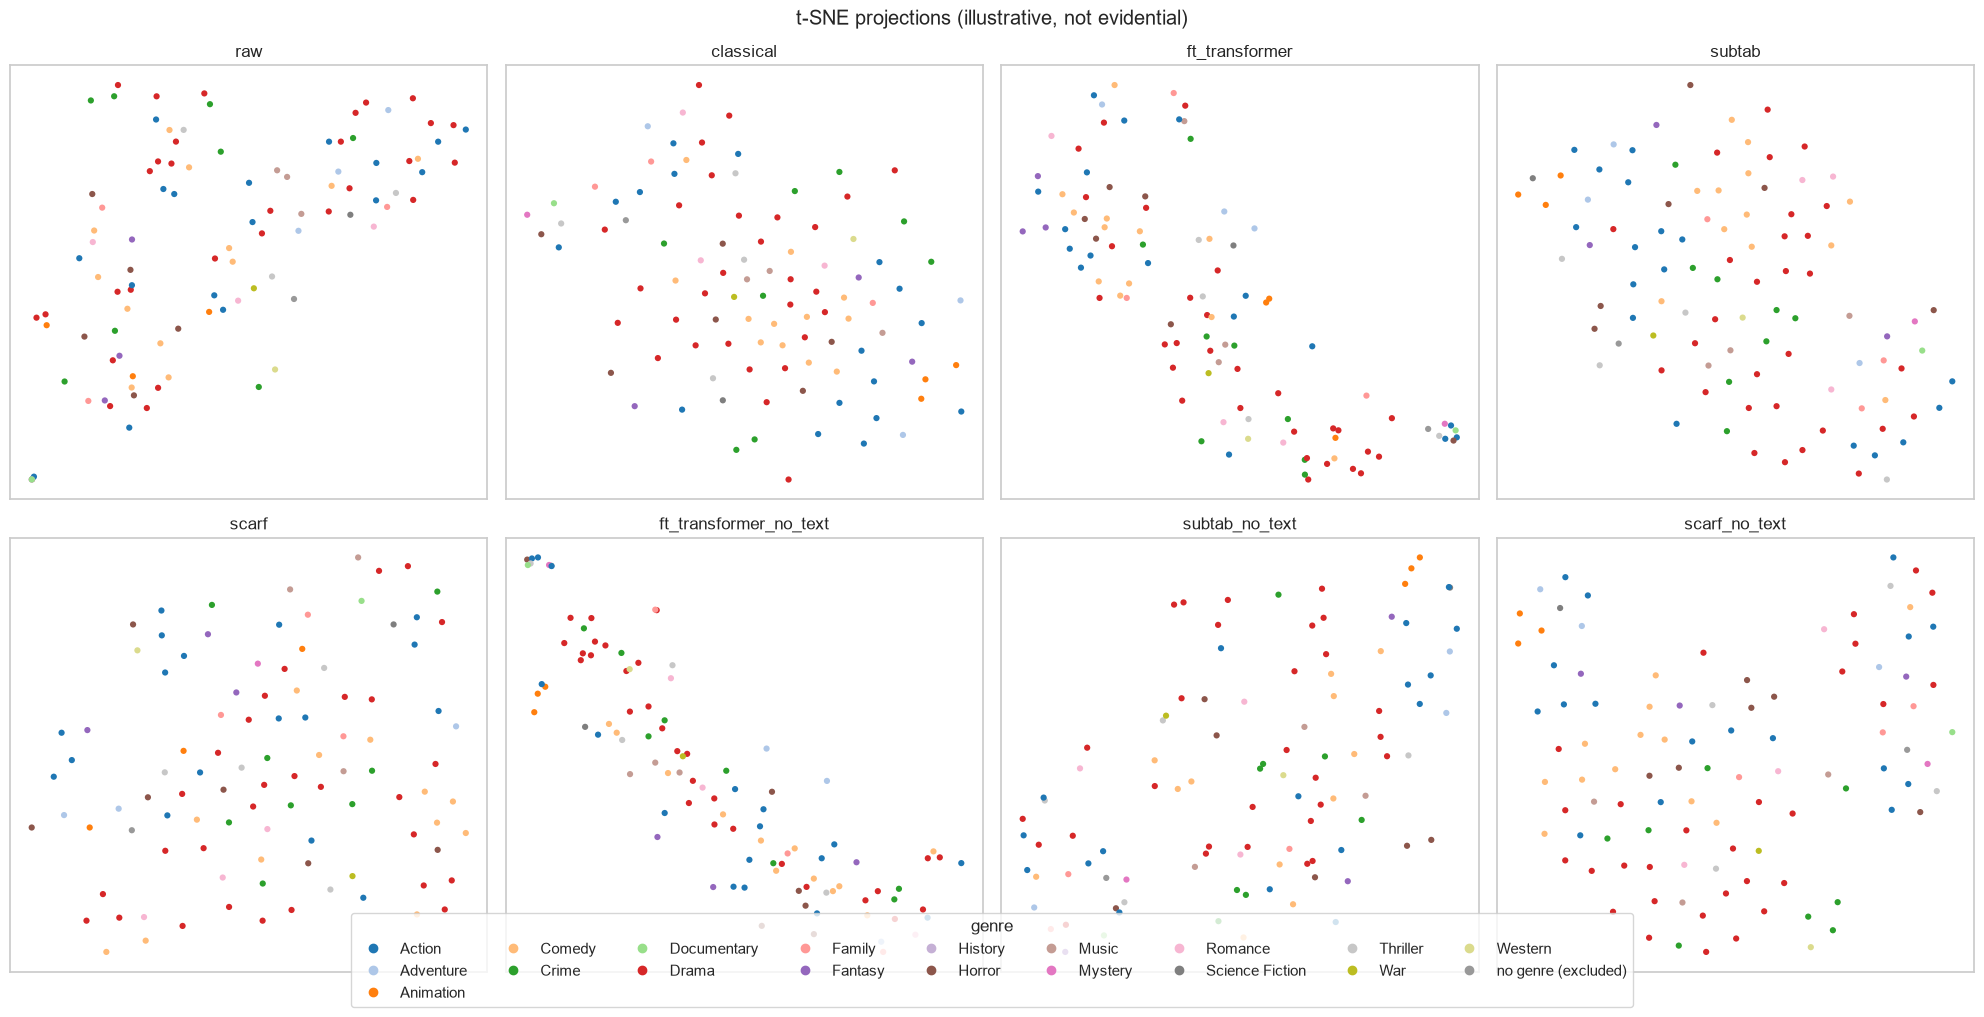

In [13]:
NO_GENRE_LABEL = "no genre (excluded)"
NO_GENRE_COLOR = (0.6, 0.6, 0.6)

genres_sorted = sorted(g for g in genre_labels["test"].unique() if pd.notna(g))
palette = sns.color_palette("tab20", n_colors=len(genres_sorted))
genre_to_color = dict(zip(genres_sorted, palette))

test_labels_array = genre_labels["test"].to_numpy()

N_GRID_COLS = 4
n_repr = len(eval_setup.REPR_NAMES)
n_grid_rows = math.ceil(n_repr / N_GRID_COLS)

fig, axes = plt.subplots(
    n_grid_rows, N_GRID_COLS, figsize=(5 * N_GRID_COLS, 5 * n_grid_rows), squeeze=False
)
axes_flat = axes.flatten()

any_no_genre = False
for ax, repr_name in zip(axes_flat, eval_setup.REPR_NAMES):
    embedding = tsne_embeddings[repr_name]
    panel_labels = test_labels_array[tsne_sample_indices[repr_name]]
    colors = []
    for g in panel_labels:
        if pd.isna(g):
            colors.append(NO_GENRE_COLOR)
            any_no_genre = True
        else:
            colors.append(genre_to_color[g])

    ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=20, edgecolor="none")
    ax.set_title(repr_name)
    ax.set_xticks([])
    ax.set_yticks([])

# Hides any trailing panel(s) left empty when n_repr isn't an exact
# multiple of N_GRID_COLS -- e.g. axes_flat[8] onward if n_repr < 8's
# next full row, an off-by-default state for the current 8 representations
# but not for an arbitrary future REPR_NAMES length.
for ax in axes_flat[n_repr:]:
    ax.axis("off")

legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=genre_to_color[g], label=g)
    for g in genres_sorted
]
if any_no_genre:
    legend_handles.append(
        plt.Line2D([0], [0], marker="o", linestyle="", color=NO_GENRE_COLOR, label=NO_GENRE_LABEL)
    )
fig.legend(
    handles=legend_handles, loc="lower center", ncol=min(len(legend_handles), 9),
    bbox_to_anchor=(0.5, -0.05 / n_grid_rows), title="genre",
)

fig.suptitle("t-SNE projections (illustrative, not evidential)")
fig.tight_layout()

savefig(fig, "06_extend_tsne_grid.png")
plt.show()

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\06_extend\06_extend_tsne_raw_runtime.png


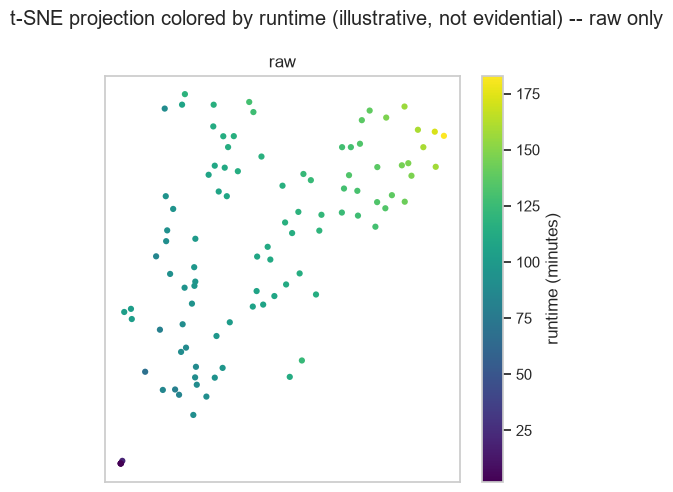

In [14]:
# Same t-SNE embedding as the grid above, but colored by runtime instead
# of genre, and only for "raw" -- runtime is a raw input feature, not an
# extractable property of the other (already-encoded) representations.
runtime_test_array = candidate_splits["test"]["runtime"].to_numpy()

repr_name = "raw"
embedding = tsne_embeddings[repr_name]
panel_runtime = runtime_test_array[tsne_sample_indices[repr_name]]

fig, ax = plt.subplots(figsize=(5, 5))
scatter = ax.scatter(
    embedding[:, 0], embedding[:, 1], c=panel_runtime, cmap="viridis", s=20, edgecolor="none"
)
ax.set_title(repr_name)
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(scatter, ax=ax, label="runtime (minutes)")

fig.suptitle(
    "t-SNE projection colored by runtime (illustrative, not evidential) -- "
    "raw only"
)
fig.tight_layout()

savefig(fig, "06_extend_tsne_raw_runtime.png")
plt.show()


vote_average used: min=4.30, max=10.00


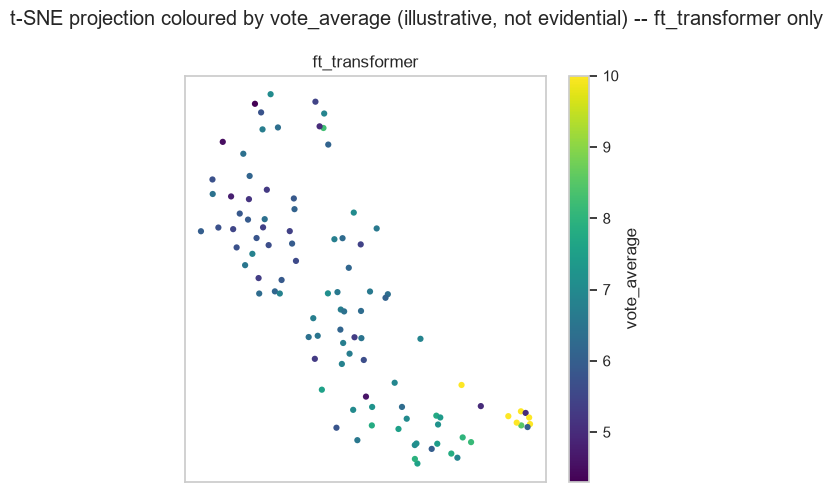

In [15]:
# Same t-SNE embedding as the grid above, but colored by vote_average
# instead of genre, and only for "ft_transformer". tsne_sample_indices
# indexes into the FULL (unmasked) test array -- fit_tsne was run on
# representations[repr_name]["test"] directly, not on a mask_test-filtered
# subset -- so vote_average is indexed the same unmasked way here, exactly
# mirroring the raw/runtime panel above. Pre-filtering by mask_test first
# (as for the genre-clustering cells) would misalign rows here: it would
# even raise an IndexError, since some of tsne_sample_indices's values
# exceed mask_test-filtered length.
vote_average_test_array = candidate_splits["test"][eval_setup.TARGET_COL].to_numpy()

repr_name = "ft_transformer"
embedding = tsne_embeddings[repr_name]
panel_vote_average = vote_average_test_array[tsne_sample_indices[repr_name]]

print(f"vote_average used: min={panel_vote_average.min():.2f}, max={panel_vote_average.max():.2f}")

fig, ax = plt.subplots(figsize=(5, 5))
scatter = ax.scatter(
    embedding[:, 0], embedding[:, 1], c=panel_vote_average, cmap="viridis", s=20, edgecolor="none"
)
ax.set_title(repr_name)
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(scatter, ax=ax, label="vote_average")

fig.suptitle(
    "t-SNE projection coloured by vote_average (illustrative, not evidential) -- "
    "ft_transformer only"
)
fig.tight_layout()

plt.show()


In [33]:
from scipy.stats import spearmanr

raw_embedding = tsne_embeddings["raw"]
raw_runtime = candidate_splits["test"]["runtime"].to_numpy()[tsne_sample_indices["raw"]]
rho_x, p_x = spearmanr(raw_embedding[:, 0], raw_runtime)
rho_y, p_y = spearmanr(raw_embedding[:, 1], raw_runtime)
print(f"raw x-axis vs runtime: rho={rho_x:.3f}, p={p_x}")
print(f"raw y-axis vs runtime: rho={rho_y:.3f}, p={p_y}")

ft_embedding = tsne_embeddings["ft_transformer"]
ft_vote_average = candidate_splits["test"]["vote_average"].to_numpy()[tsne_sample_indices["ft_transformer"]]
rho_x2, p_x2 = spearmanr(ft_embedding[:, 0], ft_vote_average)
rho_y2, p_y2 = spearmanr(ft_embedding[:, 1], ft_vote_average)
print(f"ft_transformer x-axis vs vote_average: rho={rho_x2:.3f}, p={p_x2:.4f}")
print(f"ft_transformer y-axis vs vote_average: rho={rho_y2:.3f}, p={p_y2:.4f}")

raw x-axis vs runtime: rho=0.924, p=8.382208587546149e-43
raw y-axis vs runtime: rho=0.756, p=1.026212950792443e-19
ft_transformer x-axis vs vote_average: rho=0.574, p=0.0000
ft_transformer y-axis vs vote_average: rho=-0.531, p=0.0000


## 4. Interpretability

### Fit host regressors

`host_model.fit_host_regressor` per representation, on the same shared `xgb_config`. These models exist only so LIME/SHAP have something to explain (RQ2/DO3, not a DO2 quality axis).

In [17]:
from src.evaluation import host_model

host_models = {}
for repr_name in eval_setup.REPR_NAMES:
    X_train = representations[repr_name]["train"].to_numpy()
    y_train = candidate_splits["train"][eval_setup.TARGET_COL].to_numpy()
    host_models[repr_name] = host_model.fit_host_regressor(X_train, y_train, xgb_config)
    print(f"{repr_name}: fitted")

raw: fitted
classical: fitted
ft_transformer: fitted
subtab: fitted
scarf: fitted
ft_transformer_no_text: fitted
subtab_no_text: fitted
scarf_no_text: fitted


### Evaluate host regressors

`host_model.evaluate_host` per representation on the test split.

In [18]:
host_scores_rows = {}
for repr_name in eval_setup.REPR_NAMES:
    X_test = representations[repr_name]["test"].to_numpy()
    y_test = candidate_splits["test"][eval_setup.TARGET_COL].to_numpy()
    host_scores_rows[repr_name] = host_model.evaluate_host(
        host_models[repr_name], X_test, y_test
    )

host_scores = pd.DataFrame.from_dict(host_scores_rows, orient="index")
display(host_scores)

,r2,mae
raw,0.434558,0.640079
classical,0.506800,0.592846
ft_transformer,0.321718,0.682016
subtab,0.312749,0.697120
scarf,-0.001743,0.920686
ft_transformer_no_text,0.484324,0.606655
subtab_no_text,0.462979,0.615262
scarf_no_text,0.365172,0.717020


### Fixed sample for LIME

A 100-row sample of the test split, drawn once with `config.RANDOM_SEED`. Every representation's test frame shares the same row order, so this one sample indexes correctly into all of them.

In [19]:
lime_sample_idx = np.sort(
    np.random.default_rng(config.RANDOM_SEED).choice(
        len(candidate_splits["test"]), size=100, replace=False
    )
)

print(f"lime_sample_idx: {len(lime_sample_idx)} rows sampled (seed={config.RANDOM_SEED})")
print(
    "Every representation's test frame shares candidate_splits['test']'s row "
    "order (Section 1's assert_row_alignment already confirmed this), so "
    "lime_sample_idx indexes correctly into representations[repr_name]['test'] "
    "for every repr_name -- no per-representation re-derivation needed."
)

lime_sample_idx: 100 rows sampled (seed=42)
Every representation's test frame shares candidate_splits['test']'s row order (Section 1's assert_row_alignment already confirmed this), so lime_sample_idx indexes correctly into representations[repr_name]['test'] for every repr_name -- no per-representation re-derivation needed.


### SHAP explanations

`interpretability.shap_explain` per representation on the full test split (`shap.TreeExplainer` is fast enough not to need subsampling). Also builds per-representation `feature_names`.

In [20]:
import time

from src.evaluation import interpretability

shap_values = {}
feature_names = {}

for repr_name in eval_setup.REPR_NAMES:
    X_test = representations[repr_name]["test"].to_numpy()

    if repr_name in ("raw", "classical"):
        feature_names[repr_name] = representations[repr_name]["test"].columns.tolist()
    else:
        feature_names[repr_name] = [f"dim_{i}" for i in range(X_test.shape[1])]

    start = time.time()
    shap_values[repr_name] = interpretability.shap_explain(host_models[repr_name], X_test)
    elapsed = time.time() - start
    print(f"{repr_name}: {elapsed:.1f}s ({X_test.shape[1]} features)")

raw: 0.6s (20 features)
classical: 0.4s (4286 features)
ft_transformer: 0.3s (192 features)
subtab: 0.9s (1024 features)
scarf: 0.3s (256 features)
ft_transformer_no_text: 0.4s (192 features)
subtab_no_text: 0.3s (1024 features)
scarf_no_text: 0.3s (256 features)


### LIME explanations

`interpretability.lime_explain_sample` per representation on the fixed 100-row sample. LIME fits one local surrogate per row, so this is expected to be the slowest cell after t-SNE.

In [21]:
import time

LIME_SLOW_WARNING_SECONDS = 180

lime_explanations = {}

for repr_name in eval_setup.REPR_NAMES:
    X_train = representations[repr_name]["train"].to_numpy()
    X_sample = representations[repr_name]["test"].to_numpy()[lime_sample_idx]

    start = time.time()
    lime_explanations[repr_name] = interpretability.lime_explain_sample(
        host_models[repr_name],
        X_train,
        X_sample,
        feature_names[repr_name],
        config.RANDOM_SEED,
    )
    elapsed = time.time() - start

    if elapsed > LIME_SLOW_WARNING_SECONDS:
        print(
            f"WARNING: {repr_name} took {elapsed:.1f}s (> {LIME_SLOW_WARNING_SECONDS}s) -- "
            "letting it finish rather than truncating the sample."
        )
    print(f"{repr_name}: {elapsed:.1f}s")

lime_explain_sample: explained 20/100 rows
lime_explain_sample: explained 40/100 rows
lime_explain_sample: explained 60/100 rows
lime_explain_sample: explained 80/100 rows
lime_explain_sample: explained 100/100 rows
raw: 1.7s
lime_explain_sample: explained 20/100 rows
lime_explain_sample: explained 40/100 rows
lime_explain_sample: explained 60/100 rows
lime_explain_sample: explained 80/100 rows
lime_explain_sample: explained 100/100 rows
classical: 118.6s
lime_explain_sample: explained 20/100 rows
lime_explain_sample: explained 40/100 rows
lime_explain_sample: explained 60/100 rows
lime_explain_sample: explained 80/100 rows
lime_explain_sample: explained 100/100 rows
ft_transformer: 11.6s
lime_explain_sample: explained 20/100 rows
lime_explain_sample: explained 40/100 rows
lime_explain_sample: explained 60/100 rows
lime_explain_sample: explained 80/100 rows
lime_explain_sample: explained 100/100 rows
subtab: 50.4s
lime_explain_sample: explained 20/100 rows
lime_explain_sample: explaine

### SHAP/LIME agreement

`attribution_agreement` per representation, on full (untruncated) SHAP/LIME summaries -- returns `spearman` (correlation over the union of both summaries' features, real values, no truncation or artificial tiebreak) and `overlap_at_10` (size of the two summaries' own top-10 feature-set intersection), both collected into `interpretability_table`. Also prints each representation's top-5 SHAP/LIME features, and names which features disagree for the lowest-`spearman` representation.

In [22]:
interpretability_rows = {}
top_shap = {}
top_lime = {}

for repr_name in eval_setup.REPR_NAMES:
    n_features = len(feature_names[repr_name])
    full_shap_summary = interpretability.summarize_shap(
        shap_values[repr_name], feature_names[repr_name], top_k=n_features
    )
    full_lime_summary = interpretability.summarize_lime(
        lime_explanations[repr_name], top_k=n_features
    )
    agreement = interpretability.attribution_agreement(full_shap_summary, full_lime_summary)

    interpretability_rows[repr_name] = {
        "spearman": agreement["spearman"],
        "overlap_at_10": agreement["overlap_at_10"],
    }
    top_shap[repr_name] = full_shap_summary.head(10)
    top_lime[repr_name] = full_lime_summary.head(10)

interpretability_table = pd.DataFrame.from_dict(interpretability_rows, orient="index")
display(interpretability_table)

for repr_name in eval_setup.REPR_NAMES:
    spearman = interpretability_table.loc[repr_name, "spearman"]
    overlap = interpretability_table.loc[repr_name, "overlap_at_10"]
    print(f"\n{repr_name} (spearman={spearman:.3f}, overlap@10={overlap}):")
    print(f"  top-5 SHAP: {top_shap[repr_name].head(5).index.tolist()}")
    print(f"  top-5 LIME: {top_lime[repr_name].head(5).index.tolist()}")

lowest_repr = interpretability_table["spearman"].idxmin()
shap_top5 = set(top_shap[lowest_repr].head(5).index)
shap_top10 = set(top_shap[lowest_repr].index)
lime_top5 = set(top_lime[lowest_repr].head(5).index)
lime_top10 = set(top_lime[lowest_repr].index)

disagreeing = (shap_top5 - lime_top10) | (lime_top5 - shap_top10)
print(
    f"\nLowest agreement: {lowest_repr} "
    f"(spearman={interpretability_table.loc[lowest_repr, 'spearman']:.3f}) -- "
    "feature(s) top-5 in one method but absent from the other's top-10: "
    f"{sorted(disagreeing) if disagreeing else 'none'}"
)

,spearman,overlap_at_10
raw,0.883126,9
classical,0.281160,7
ft_transformer,0.297314,7
subtab,0.094630,2
scarf,0.037177,3
ft_transformer_no_text,0.249778,4
subtab_no_text,0.086764,3
scarf_no_text,0.040380,3



raw (spearman=0.883, overlap@10=9):
  top-5 SHAP: ['runtime', 'popularity', 'budget', 'release_year', 'revenue']
  top-5 LIME: ['budget', 'popularity', 'revenue', 'release_year', 'production_companies']

classical (spearman=0.281, overlap@10=7):
  top-5 SHAP: ['popularity', 'runtime', 'budget', 'release_year', 'genres_Drama']
  top-5 LIME: ['budget', 'popularity', 'revenue', 'genres_Documentary', 'runtime']

ft_transformer (spearman=0.297, overlap@10=7):
  top-5 SHAP: ['dim_65', 'dim_56', 'dim_154', 'dim_162', 'dim_143']
  top-5 LIME: ['dim_65', 'dim_154', 'dim_56', 'dim_162', 'dim_58']

subtab (spearman=0.095, overlap@10=2):
  top-5 SHAP: ['dim_844', 'dim_387', 'dim_498', 'dim_55', 'dim_418']
  top-5 LIME: ['dim_387', 'dim_844', 'dim_18', 'dim_785', 'dim_801']

scarf (spearman=0.037, overlap@10=3):
  top-5 SHAP: ['dim_113', 'dim_248', 'dim_88', 'dim_111', 'dim_107']
  top-5 LIME: ['dim_111', 'dim_48', 'dim_9', 'dim_254', 'dim_183']

ft_transformer_no_text (spearman=0.250, overlap@10=

## 5. Recoverability

### Shared language label encoding

One `LabelEncoder` fit on train's `original_language`, reused for every split and representation so confusion matrices are comparable. Asserts no unseen test-split language before transforming.

In [23]:
from sklearn.preprocessing import LabelEncoder

print("candidate_splits['train']['original_language'].value_counts():")
print(candidate_splits["train"][eval_setup.SENSITIVE_COL].value_counts())

lang_encoder = LabelEncoder()
lang_encoder.fit(candidate_splits["train"][eval_setup.SENSITIVE_COL])

unseen_test_langs = set(candidate_splits["test"][eval_setup.SENSITIVE_COL].unique()) - set(
    lang_encoder.classes_
)
assert not unseen_test_langs, (
    f"candidate_splits['test']['original_language'] contains value(s) never seen in train: "
    f"{unseen_test_langs} -- the D26 rare-language-bucketing assumption "
    "(03_feature_split.ipynb) was not applied consistently across splits and needs "
    "re-checking there, not silently working around here"
)

y_lang = {
    split: lang_encoder.transform(candidate_splits[split][eval_setup.SENSITIVE_COL])
    for split in config.SPLIT_NAMES
}

print()
print(f"lang_encoder.classes_: {lang_encoder.classes_.tolist()}")
for split in config.SPLIT_NAMES:
    print(f"y_lang[{split!r}]: {y_lang[split].shape}")

print(f"y_lang['test'] majority-class proportion: {pd.Series(y_lang['test']).value_counts(normalize=True).max():.4f}")

candidate_splits['train']['original_language'].value_counts():
original_language
en       6519
other    1063
hi        250
fr        243
ru        166
es        162
Name: count, dtype: int64

lang_encoder.classes_: ['en', 'es', 'fr', 'hi', 'other', 'ru']
y_lang['train']: (8403,)
y_lang['val']: (1050,)
y_lang['test']: (1051,)
y_lang['test'] majority-class proportion: 0.7755


### Fit recoverability probes

`fairness.fit_recoverability_probe` per representation, on the same shared `xgb_config`. `raw`/`classical` fit on the sensitive-attribute-safe columns; the three embeddings are opaque, so nothing to drop.

In [24]:
from src.evaluation import fairness

fairness_probes = {}

for repr_name in eval_setup.REPR_NAMES:
    if repr_name == "raw":
        X_train = raw_features_safe["train"].to_numpy()
    elif repr_name == "classical":
        X_train = classical_features_safe["train"].to_numpy()
    else:
        X_train = representations[repr_name]["train"].to_numpy()

    fairness_probes[repr_name] = fairness.fit_recoverability_probe(
        X_train, y_lang["train"], xgb_config
    )
    print(f"{repr_name}: fitted")
    if repr_name in ("raw", "classical"):
        print(f"  {repr_name} feature count used: {X_train.shape[1]}")

raw: fitted
  raw feature count used: 19
classical: fitted
  classical feature count used: 4279
ft_transformer: fitted
subtab: fitted
scarf: fitted
ft_transformer_no_text: fitted
subtab_no_text: fitted
scarf_no_text: fitted


### Evaluate recoverability and amplification

`fairness.evaluate_probe` per representation, with `delta_accuracy`/`delta_macro_f1` computed against `raw` (`NaN` for `raw` itself). Positive = amplified, negative = obscured; flags any representation where the two deltas disagree in sign.

In [25]:
fairness_rows = {}

for repr_name in eval_setup.REPR_NAMES:
    if repr_name == "raw":
        X_test = raw_features_safe["test"].to_numpy()
    elif repr_name == "classical":
        X_test = classical_features_safe["test"].to_numpy()
    else:
        X_test = representations[repr_name]["test"].to_numpy()

    fairness_rows[repr_name] = fairness.evaluate_probe(
        fairness_probes[repr_name], X_test, y_lang["test"]
    )

fairness_table = pd.DataFrame.from_dict(fairness_rows, orient="index")
fairness_table["delta_accuracy"] = np.nan
fairness_table["delta_macro_f1"] = np.nan

raw_accuracy = fairness_table.loc["raw", "accuracy"]
raw_macro_f1 = fairness_table.loc["raw", "macro_f1"]

for repr_name in eval_setup.REPR_NAMES:
    if repr_name == "raw":
        continue
    fairness_table.loc[repr_name, "delta_accuracy"] = fairness.compute_amplification(
        fairness_table.loc[repr_name, "accuracy"], raw_accuracy
    )
    fairness_table.loc[repr_name, "delta_macro_f1"] = fairness.compute_amplification(
        fairness_table.loc[repr_name, "macro_f1"], raw_macro_f1
    )

display(fairness_table)

for repr_name in eval_setup.REPR_NAMES:
    if repr_name == "raw":
        continue
    delta_acc = fairness_table.loc[repr_name, "delta_accuracy"]
    delta_f1 = fairness_table.loc[repr_name, "delta_macro_f1"]

    if delta_acc > 0:
        direction = "amplifies"
    elif delta_acc < 0:
        direction = "obscures"
    else:
        direction = "neither amplifies nor obscures (delta_accuracy == 0)"

    sentence = (
        f"{repr_name} {direction} the sensitive attribute relative to raw "
        f"(delta_accuracy={delta_acc:+.4f})"
    )

    if np.sign(delta_acc) != np.sign(delta_f1):
        sentence += (
            f" -- but delta_macro_f1={delta_f1:+.4f} disagrees in sign, "
            "worth a line in 3.5's prose"
        )
    print(sentence)

,accuracy,macro_f1,delta_accuracy,delta_macro_f1
raw,0.886775,0.528856,NaN,NaN
classical,0.979068,0.958143,0.092293,0.429287
ft_transformer,0.922931,0.727045,0.036156,0.198189
subtab,0.949572,0.814831,0.062797,0.285974
scarf,0.769743,0.186387,-0.117031,-0.342469
ft_transformer_no_text,0.974310,0.912972,0.087536,0.384116
subtab_no_text,0.998097,0.998523,0.111323,0.469667
scarf_no_text,0.963844,0.865731,0.077069,0.336874


classical amplifies the sensitive attribute relative to raw (delta_accuracy=+0.0923)
ft_transformer amplifies the sensitive attribute relative to raw (delta_accuracy=+0.0362)
subtab amplifies the sensitive attribute relative to raw (delta_accuracy=+0.0628)
scarf obscures the sensitive attribute relative to raw (delta_accuracy=-0.1170)
ft_transformer_no_text amplifies the sensitive attribute relative to raw (delta_accuracy=+0.0875)
subtab_no_text amplifies the sensitive attribute relative to raw (delta_accuracy=+0.1113)
scarf_no_text amplifies the sensitive attribute relative to raw (delta_accuracy=+0.0771)


### release_year vs original_language check

Re-runs `02_preprocessing.ipynb`'s Kruskal-Wallis check directly on `candidate_splits["train"]`/`["test"]`, printed alongside the hand-copied pre-split H/p figures. Warns if a split's association is no longer significant.

In [26]:
from scipy.stats import kruskal

# Hand-copied from reports/eda_log.md's most recent 02_preprocessing.ipynb run
# for the active candidate (config.ACTIVE_CANDIDATE == "br_gt0", i.e.
# tmdb_budget_revenue_gt0) -- NOT recomputed here, since it was run on the
# full pre-split candidate, not on candidate_splits.
H_PRESPLIT, P_PRESPLIT = 435.69, 3.282e-88

SIGNIFICANCE_ALPHA = 0.05

split_results = {}
for split in ("train", "test"):
    df = candidate_splits[split]
    langs_in_split = sorted(df[eval_setup.SENSITIVE_COL].unique())
    groups = [
        df.loc[df[eval_setup.SENSITIVE_COL] == lang, "release_year"].dropna()
        for lang in langs_in_split
    ]
    h_stat, p_value = kruskal(*groups)
    split_results[split] = (h_stat, p_value)
    print(f"{split}: H={h_stat:.2f}, p={p_value:.4g} ({len(groups)} language groups: {langs_in_split})")

print()
print("Pre-split vs train vs test, side by side:")
print(f"  pre-split ({config.ACTIVE_CANDIDATE}, 02_preprocessing.ipynb): H={H_PRESPLIT:.2f}, p={P_PRESPLIT:.4g}")
print(f"  train:                                          H={split_results['train'][0]:.2f}, p={split_results['train'][1]:.4g}")
print(f"  test:                                           H={split_results['test'][0]:.2f}, p={split_results['test'][1]:.4g}")

for split in ("train", "test"):
    h_stat, p_value = split_results[split]
    if p_value >= SIGNIFICANCE_ALPHA:
        print(
            f"\nWARNING: the {split} split's release_year-vs-{eval_setup.SENSITIVE_COL} "
            f"association is NOT significant at alpha={SIGNIFICANCE_ALPHA} (p={p_value:.4g}). "
            "The pre-split Kruskal-Wallis result does not straightforwardly carry over to "
            f"this split -- the 'why delta_accuracy is relative to raw' worked example in "
            f"3.5's prose needs re-examining for the {split} split before it goes in. Do not "
            "fall back on the pre-split H/p figure as if it still made the same point here."
        )


train: H=433.72, p=1.59e-91 (6 language groups: ['en', 'es', 'fr', 'hi', 'other', 'ru'])
test: H=95.04, p=5.861e-19 (6 language groups: ['en', 'es', 'fr', 'hi', 'other', 'ru'])

Pre-split vs train vs test, side by side:
  pre-split (br_gt0, 02_preprocessing.ipynb): H=435.69, p=3.282e-88
  train:                                          H=433.72, p=1.59e-91
  test:                                           H=95.04, p=5.861e-19


## 6. Trade-off

### Assemble the trade-off table

`tradeoff.assemble_raw_table` pulls one column each from `clustering_table`, `interpretability_table`, and `fairness_table`. The host regressor's r2/mae never belongs here (a DO3 sanity check, not a DO2 quality axis) -- confirm by eye: 8 rows (one per `REPR_NAMES` entry), 5 columns, no host-model column.

In [27]:
from src.evaluation import tradeoff

raw_tradeoff_table = tradeoff.assemble_raw_table(
    clustering_table, interpretability_table, fairness_table
)

print(f"raw_tradeoff_table: {raw_tradeoff_table.shape[0]} rows, {raw_tradeoff_table.shape[1]} columns")
print(f"columns: {raw_tradeoff_table.columns.tolist()}")
display(raw_tradeoff_table)

raw_tradeoff_table: 8 rows, 5 columns
columns: ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'agreement', 'delta_macro_f1']


,silhouette,calinski_harabasz,davies_bouldin,agreement,delta_macro_f1
raw,-0.297984,5.129236,9.868451,0.883126,0.000000
classical,-0.085134,5.554086,5.081278,0.281160,0.429287
ft_transformer,-0.279115,5.230553,7.900167,0.297314,0.198189
subtab,-0.118872,9.698949,5.143625,0.094630,0.285974
scarf,-0.264919,3.702495,8.861269,0.037177,-0.342469
ft_transformer_no_text,-0.296572,7.001909,6.588351,0.249778,0.384116
subtab_no_text,-0.135893,6.980652,5.347375,0.086764,0.469667
scarf_no_text,-0.264927,12.319800,5.136824,0.040380,0.336874


### Normalise and save

`tradeoff.normalize_metrics`, displayed stacked with `raw_tradeoff_table` so the normalisation's effect is visible. Both saved to `EVALUATION_DIR`. This is the last computation in this notebook.

In [28]:
normalized_tradeoff_table = tradeoff.normalize_metrics(raw_tradeoff_table)

comparison = pd.concat({"raw": raw_tradeoff_table, "normalized": normalized_tradeoff_table}, axis=1)
display(comparison)

EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

raw_tradeoff_path = EVALUATION_DIR / "06_extend_raw_tradeoff_metrics.csv"
raw_tradeoff_table.to_csv(raw_tradeoff_path)
print(f"Saved: {raw_tradeoff_path}")

normalized_tradeoff_path = EVALUATION_DIR / "06_extend_normalized_tradeoff_metrics.csv"
normalized_tradeoff_table.to_csv(normalized_tradeoff_path)
print(f"Saved: {normalized_tradeoff_path}")

raw                                             \
                       silhouette calinski_harabasz davies_bouldin agreement   
raw                     -0.297984          5.129236       9.868451  0.883126   
classical               -0.085134          5.554086       5.081278  0.281160   
ft_transformer          -0.279115          5.230553       7.900167  0.297314   
subtab                  -0.118872          9.698949       5.143625  0.094630   
scarf                   -0.264919          3.702495       8.861269  0.037177   
ft_transformer_no_text  -0.296572          7.001909       6.588351  0.249778   
subtab_no_text          -0.135893          6.980652       5.347375  0.086764   
scarf_no_text           -0.264927         12.319800       5.136824  0.040380   

                                      normalized                    \
                       delta_macro_f1 silhouette calinski_harabasz   
raw                          0.000000   0.000000          0.165567   
classical                    0.429287   1.000000          0.214869   
ft_transformer               0.198189   0.088650          0.177324   
subtab                       0.285974   0.841492          0.695862   
scarf                       -0.342469   0.155344          0.000000   
ft_transformer_no_text       0.384116   0.006633          0.382882   
subtab_no_text               0.469667   0.761525          0.380416   
scarf_no_text                0.336874   0.155307          1.000000   

                                                                
                       davies_bouldin agreement delta_macro_f1  
raw                          0.000000  1.000000       0.578311  
classical                    1.000000  0.288414       0.049721  
ft_transformer               0.411158  0.307509       0.334277  
subtab                       0.986976  0.067916       0.226185  
scarf                        0.210392  0.000000       1.000000  
ft_transformer_no_text       0.685185  0.251317       0.105341  
subtab_no_text               0.944415  0.058617       0.000000  
scarf_no_text                0.988397  0.003787       0.163511

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\evaluation\06_extend_raw_tradeoff_metrics.csv
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\evaluation\06_extend_normalized_tradeoff_metrics.csv


### Trade-off visualisation
Parallel-coordinates plot of normalized_tradeoff_table -- one line per representation
across the five normalised axes, so crossing lines show where axes oppose each other and
parallel lines show where they reinforce. This is Figure 4.4.

,silhouette,calinski_harabasz,davies_bouldin,agreement,delta_macro_f1
raw,0.000000,0.165567,0.000000,1.000000,0.578311
classical,1.000000,0.214869,1.000000,0.288414,0.049721
ft_transformer,0.088650,0.177324,0.411158,0.307509,0.334277
subtab,0.841492,0.695862,0.986976,0.067916,0.226185
scarf,0.155344,0.000000,0.210392,0.000000,1.000000
ft_transformer_no_text,0.006633,0.382882,0.685185,0.251317,0.105341
subtab_no_text,0.761525,0.380416,0.944415,0.058617,0.000000
scarf_no_text,0.155307,1.000000,0.988397,0.003787,0.163511


Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\06_extend\06_extend_tradeoff_parallel_coordinates.png


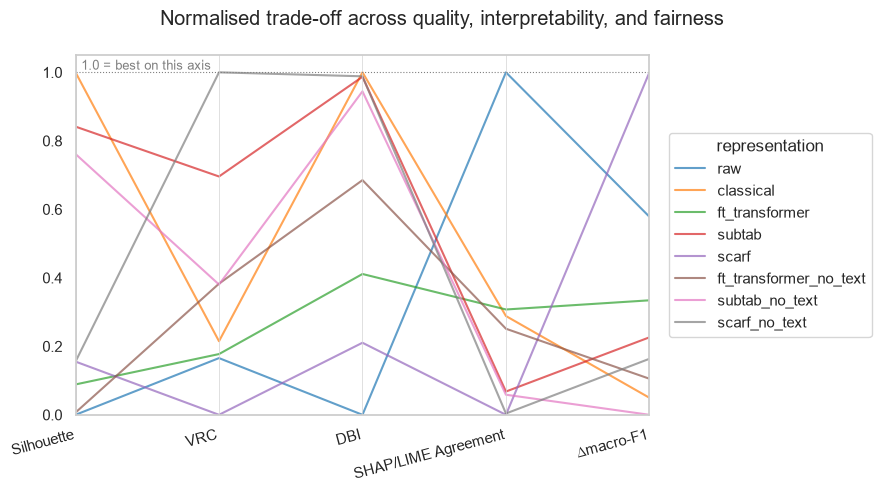

In [29]:
display(normalized_tradeoff_table)

AXIS_ORDER = ["silhouette", "calinski_harabasz", "davies_bouldin", "agreement", "delta_macro_f1"]
AXIS_LABELS = {
    "silhouette": "Silhouette",
    "calinski_harabasz": "VRC",
    "davies_bouldin": "DBI",
    "agreement": "SHAP/LIME Agreement",
    "delta_macro_f1": "∆macro-F1",
}

plot_df = normalized_tradeoff_table.rename_axis("representation").reset_index()
plot_df = plot_df.rename(columns=AXIS_LABELS)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.get_cmap("tab10").colors[: len(plot_df)]
pd.plotting.parallel_coordinates(
    plot_df, "representation", cols=[AXIS_LABELS[col] for col in AXIS_ORDER], color=colors, ax=ax,
    axvlines_kwds={"linewidth": 0.5, "color": "lightgrey"}, alpha=0.70,
)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle=":")
ax.text(
    0.01, 1.0, "1.0 = best on this axis", fontsize=9, color="grey",
    transform=ax.get_yaxis_transform(), va="bottom",
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="representation", loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.suptitle("Normalised trade-off across quality, interpretability, and fairness")
fig.tight_layout()

savefig(fig, "06_extend_tradeoff_parallel_coordinates.png")
plt.show()


## 7. Log summary

In [30]:
from src.report import log_findings

EVALUATION_PROTOCOL_LOG_PATH = config.REPORTS_DIR / "evaluation_protocol_log.md"

y_lang_test_majority = pd.Series(y_lang["test"]).value_counts(normalize=True).max()

findings = {
    "Representations compared": list(eval_setup.REPR_NAMES),
    "Row alignment": (
        f"id-verified for all {len(eval_setup.REPR_NAMES)} representations across "
        f"{', '.join(f'{split}={len(df)}' for split, df in candidate_splits.items())}"
    ),
    "Genre label exclusions (no first genre)": {
        split: int((~genre_valid_mask[split]).sum()) for split in config.SPLIT_NAMES
    },
    "Sensitive-attribute columns dropped (before -> after)": {
        "raw": f"{raw_before} -> {raw_after}",
        "classical": f"{classical_before} -> {classical_after}",
    },
    "Table 4.2 clustering metrics": clustering_table.round(4).to_dict(orient="index"),
    "Silhouette subsample variance (mean/std over 20 draws)": (
        silhouette_variance_table.round(4).to_dict(orient="index")
    ),
    "Standardisation scale-artefact check (raw silhouette, as-is vs standardised)": {
        "as-is": round(float(raw_silhouette_as_is), 4),
        "standardised": round(float(standardised_metrics["silhouette"]), 4),
    },
    "t-SNE params": tsne_params,
    "Host regressor scores (r2/mae)": host_scores.round(4).to_dict(orient="index"),
    "SHAP/LIME agreement (spearman/overlap_at_10)": (
        interpretability_table.round(4).to_dict(orient="index")
    ),
    "Lowest SHAP/LIME agreement": (
        f"{lowest_repr} -- disagreeing features: {sorted(disagreeing) if disagreeing else 'none'}"
    ),
    "y_lang['test'] majority-class proportion": round(float(y_lang_test_majority), 4),
    "Recoverability/fairness (accuracy/macro_f1/delta_accuracy/delta_macro_f1)": (
        fairness_table.round(4).to_dict(orient="index")
    ),
    "release_year vs original_language (Kruskal-Wallis H/p)": {
        split: {"H": round(h, 2), "p": p} for split, (h, p) in split_results.items()
    },
    "Trade-off table (raw)": raw_tradeoff_table.round(4).to_dict(orient="index"),
    "Trade-off table (normalized)": normalized_tradeoff_table.round(4).to_dict(orient="index"),
    "Saved outputs": (
        f"{clustering_metrics_path}, {raw_tradeoff_path}, {normalized_tradeoff_path}"
    ),
}

log_findings(
    title="06 Extended Evaluation Protocol: TMDB -- summary",
    findings=findings,
    figures=["reports/figures/06_extend/06_extend_tsne_grid.png"],
    log_path=EVALUATION_PROTOCOL_LOG_PATH,
    log_title="Evaluation Protocol Log",
)
print(f"Logged summary to {EVALUATION_PROTOCOL_LOG_PATH}")

Logged summary to C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\evaluation_protocol_log.md
